## Exercise 4
### Hydrogen Burning

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt

For an easy access to the cross sections we import another package. With this package it is possible to read reaclib files and to get the cross sections at a specific temperature.  

In [2]:
from class_files.reaclib_class import reaclib

# For this, we have to give the path of the Reaclib file
r = reaclib("hburning_reactions.dat")
r.read_reaclib()
import warnings
warnings.filterwarnings('ignore')

Reading line 705         


In [3]:
# With the class we can now access all reactions that are contained in the Reaclib
# For this we have to call the function "get_rate_at_temp", followed by the temperature in GK, 
# the reactants as a list, and the products as a list. The return value will be Avogadros number (NA)
# times the cross section at the given temperature.
# For example, we can access <ov>_pp * NA at 0.015 GK by:
NA_sigma_pp = r.get_rate_at_temp(0.015,["p","p"],["d"])

In [18]:
# Run winnet
! /home/teaching/WinNet/bin/winnet Hydrogen_burning.par >OUT 2>ERR

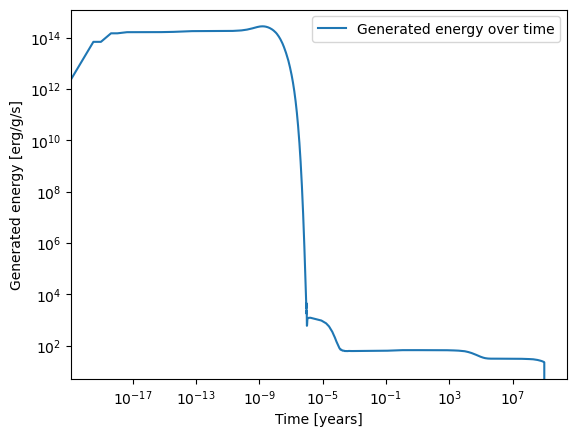

In [6]:
data = np.loadtxt("generated_energyT0.015GK..dat", skiprows=1)

time = data[:, 0]
totalenergy = data[:, 1]

plt.plot(time / (365*24*3600), totalenergy, label="Generated energy over time")
plt.xlabel('Time [years]')
plt.ylabel('Generated energy [erg/g/s]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

We can observe that the generated energy increased in the first few moments and then remains more or less constant over a long time period. After that it experiences two dip at around 1e-5 years, one being pretty sharp and the other one being more soft. In the end, the generated energy is somewhat constant again until it reaches zero at the end of the time interval.

In [10]:
trackT1 = np.loadtxt("tracked_nucleiT0.015GK.dat", skiprows=1)

timeT1 = trackT1[:, 0]
Y_p = trackT1[:, 1]
Y_d = trackT1[:, 2]
Y_he3 = trackT1[:, 3]
Y_he4 = trackT1[:, 4]